# Extract Building Data from `train.csv`

This notebook filters `train.csv` for a specific building and meter type, and saves the slice to `data/building/<building_id>/`.

In [13]:
import os
import pandas as pd

# Parameters
BUILDING_ID = 1074
METER = 0  # 0: electricity, 1: chilledwater, 2: steam, 3: hotwater

In [14]:
# Load train.csv and slice building data in one go
train = pd.read_csv('../data/train.csv')
building_df = train[(train['building_id'] == BUILDING_ID) & (train['meter'] == METER)].copy()
building_df['timestamp'] = pd.to_datetime(building_df['timestamp'])
building_df = building_df.sort_values('timestamp').reset_index(drop=True)

print(f'Extracted {len(building_df)} rows for Building {BUILDING_ID}, Meter {METER}')
building_df.head()


Extracted 8784 rows for Building 1074, Meter 0


,building_id,meter,timestamp,meter_reading
0,1074,0,2016-01-01 00:00:00,39.249
1,1074,0,2016-01-01 01:00:00,39.249
2,1074,0,2016-01-01 02:00:00,37.862
3,1074,0,2016-01-01 03:00:00,35.834
4,1074,0,2016-01-01 04:00:00,35.495


In [15]:
# Save to data/building/<BUILDING_ID>/
output_dir = f"../data/building/{BUILDING_ID}"
os.makedirs(output_dir, exist_ok=True)

output_path = f"{output_dir}/building_{BUILDING_ID}.csv"
building_df.to_csv(output_path, index=False)

print(f"Saved to {output_path}")

Saved to ../data/building/1074/building_1074.csv


<Axes: title={'center': 'Building 1074 - Meter 0'}, xlabel='timestamp'>

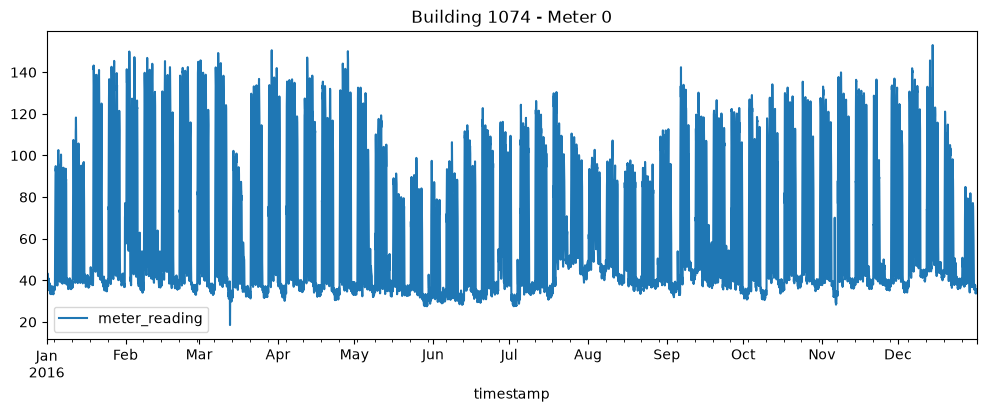

In [16]:
# Quick sanity check plot
building_df.plot(x='timestamp', y='meter_reading', figsize=(12, 4), title=f'Building {BUILDING_ID} - Meter {METER}')